# Reporte de Modelado ML — Reclutamiento a Comisiones por Época Política
**Diputrax · Versión 1.0 · 2026-04-22**

---

Este reporte consolida resultados, hallazgos e interpretaciones del notebook `ml_comisiones.ipynb`. No re-entrena modelos: muestra los resultados ya computados y analiza su significado político-institucional.

### Alcance
| Ítem | Detalle |
|:-----|:--------|
| **Fuente** | `diputados_20260421_205712.parquet` · 5,000 registros · 78 columnas |
| **Targets** | Nodales (binario), Lastre (binario), Temáticas (conteo Poisson) |
| **Épocas** | ERA_1 PRI (57-59), ERA_2 PAN (60-62), ERA_3 Transición (63-65), ERA_4 Morena (66) |
| **Modelos** | Regresión Logística · Random Forest · XGBoost · GLM Poisson |
| **Explicabilidad** | SHAP (TreeExplainer) · Beeswarm · Heatmap · Waterfall |
| **Validación** | 5-fold CV estratificado + Rolling Forward entre épocas |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from IPython.display import display

IMG_DIR = Path("reports/eda")

def show_img(fname, title=None, figsize=(16, 10)):
    img = mpimg.imread(IMG_DIR / fname)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    plt.tight_layout()
    plt.show()

pd.set_option("display.float_format", "{:.3f}".format)
print("Setup OK")

Setup OK


---
## 1. Contexto y Diseño del Estudio

### 1.1 Pregunta de investigación

> **¿El perfil biográfico, educativo y de trayectoria de un diputado predice a qué tipo de comisión es asignado, y ese perfil ha cambiado entre épocas políticas?**

### 1.2 Tipología de comisiones

| Tipo | Definición operacional | Implicación política |
|:-----|:----------------------|:---------------------|
| **Nodal** | ≥1 comisión nodal (presupuesto, hacienda, seguridad) | Alta influencia · cargo de confianza del grupo mayoritario |
| **Lastre** | ≥1 comisión lastre (sin recursos ni dictámenes) | Marginalización · oposición o primiparos sin red |
| **Temática** | Conteo de comisiones temáticas (0–10) | Especialización · volumen de trabajo legislativo |

### 1.3 Épocas y distribución de datos

| Época | Legislaturas | Régimen | n | Tasa nodal | Tasa lastre | Media temáticas |
|:------|:------------|:--------|--:|----------:|----------:|---------------:|
| ERA_1 | 57–59 | PRI hegemónico | 1500 | 32.2% | 42.1% | 1.53 |
| ERA_2 | 60–62 | Alternancia PAN | 1500 | 40.7% | 45.9% | 1.93 |
| ERA_3 | 63–65 | Transición | 1500 | 49.5% | 49.9% | 2.15 |
| ERA_4 | 66 | Morena | 500 | 55.4% | 39.2% | 1.87 |

**Nota:** ERA_4 tiene sólo una legislatura (n=500). Intervalos de confianza más amplios — interpretar con cautela.

### 1.4 Feature engineering (86 features)

| Bloque | Variables clave |
|:-------|:---------------|
| Político-electoral | `es_partido_mayoria`, `mayoria_relativa`, `n_cargos_legislativos_prev`, `fue_senador` |
| Trayectoria | `n_trayectoria_admin`, `n_trayectoria_politica`, `n_trayectoria_legislativa`, `nivel_cargo_max` |
| Educación | `grado_estudios_ord`, `tiene_posgrado`, `univ_elite`, `estudios_en_extranjero` |
| Compuestos | `carrera_depth` (admin+pol+leg), `edu_calidad` (grado+posgrado+extranjero) |
| Cargos ejecutivos | `fue_secretario_cargo`, `fue_director_general`, `fue_subsecretario` |
| Dummies | Partido (7 cats), Región (5), Área de formación |

---
## 2. Comisiones Nodales — Clasificación Binaria

**Hipótesis:** las comisiones nodales se asignan a diputados del partido mayoritario con experiencia administrativa y trayectoria política probada.

In [2]:
df_nodal = pd.DataFrame([
    {"Época": "ERA 1 — PRI (57-59)",       "n": 1500, "pos%": "32.2%", "LR AUC": 0.734, "RF AUC": 0.719, "XGB AUC": 0.719, "Mejor": "LR"},
    {"Época": "ERA 2 — PAN (60-62)",       "n": 1500, "pos%": "40.7%", "LR AUC": 0.720, "RF AUC": 0.725, "XGB AUC": 0.718, "Mejor": "RF"},
    {"Época": "ERA 3 — Transición (63-65)", "n": 1500, "pos%": "49.5%", "LR AUC": 0.699, "RF AUC": 0.677, "XGB AUC": 0.694, "Mejor": "LR"},
    {"Época": "ERA 4 — Morena (66)",        "n":  500, "pos%": "55.4%", "LR AUC": 0.619, "RF AUC": 0.643, "XGB AUC": 0.602, "Mejor": "RF"},
])
display(df_nodal.set_index("Época"))

,n,pos%,LR AUC,RF AUC,XGB AUC,Mejor
Época,,,,,,
ERA 1 — PRI (57-59),1500,32.2%,0.734,0.719,0.719,LR
ERA 2 — PAN (60-62),1500,40.7%,0.720,0.725,0.718,RF
ERA 3 — Transición (63-65),1500,49.5%,0.699,0.677,0.694,LR
ERA 4 — Morena (66),500,55.4%,0.619,0.643,0.602,RF


### 2.1 Interpretación — Nodales

**Señal decreciente a lo largo del tiempo.** El AUC cae de 0.734 (ERA_1) a 0.619–0.643 (ERA_4), lo que indica que el perfil biográfico predice progresivamente peor quién obtiene una comisión nodal.

| Rango AUC | Lectura |
|:----------|:--------|
| 0.50 | Aleatorio |
| 0.55–0.65 | Señal débil |
| **0.65–0.75** | **Señal moderada — rango ERA_1/ERA_2/ERA_3** |
| 0.75–0.85 | Señal fuerte |

**Hallazgos clave:**
- **ERA_1 (PRI)** es la época más predecible (LR 0.734). El PRI operaba con criterios más formalizados y ligados a la trayectoria administrativa dentro del sistema.
- **ERA_2 (PAN)** mantiene señal similar (RF 0.725). La alternancia no rompe la lógica de asignación basada en perfil.
- **ERA_3 (Transición)** empieza a degradarse (LR 0.699). Mayor fragmentación partidista → criterios menos centralizados.
- **ERA_4 (Morena)** caída notable a 0.619–0.643. La lógica de asignación en el bloque Morena incorpora factores no observados en el perfil biográfico (lealtad, territorio, red interna). *Con n=500, el intervalo ±0.06 es amplio — resultado orientativo.*

**Modelo ganador:** Regresión Logística compite o gana en 3 de 4 épocas. Sugiere que la relación entre perfil y asignación nodal es en gran parte **lineal** — las interacciones capturadas por RF/XGB no agregan valor sustancial.

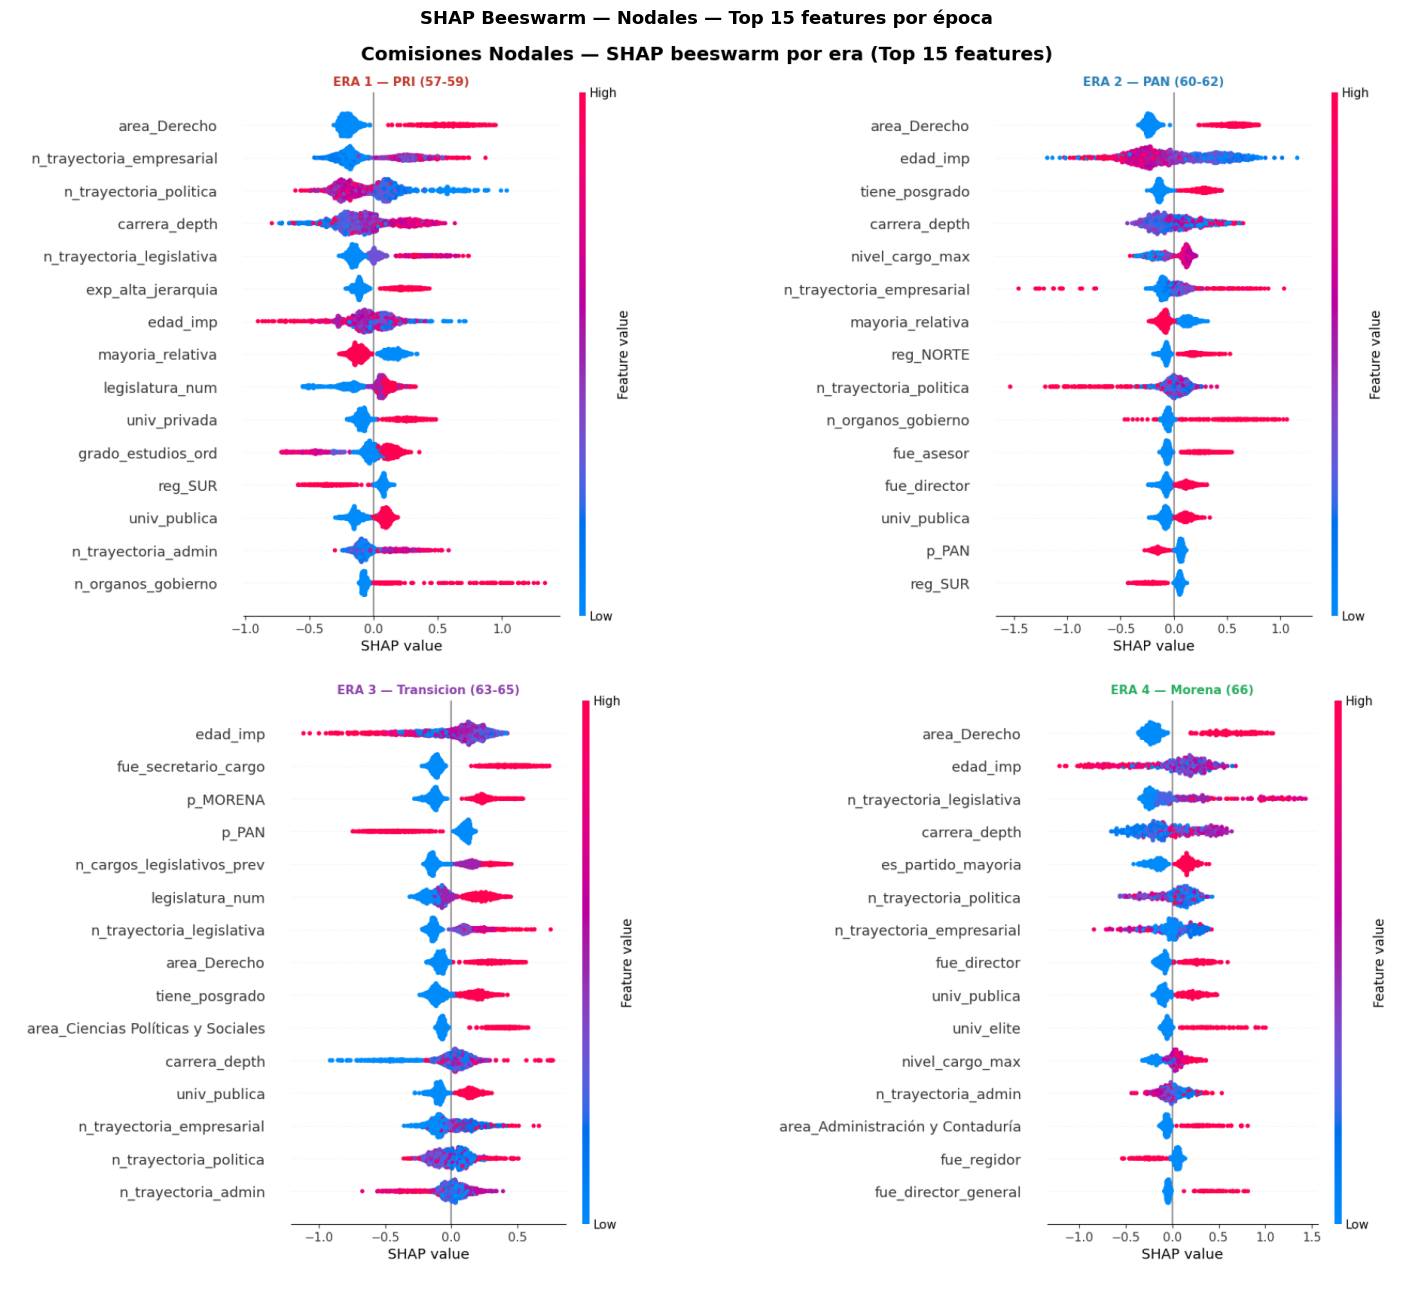

In [3]:
show_img("shap_nodales_beeswarm.png",
         "SHAP Beeswarm — Nodales — Top 15 features por época",
         figsize=(18, 13))

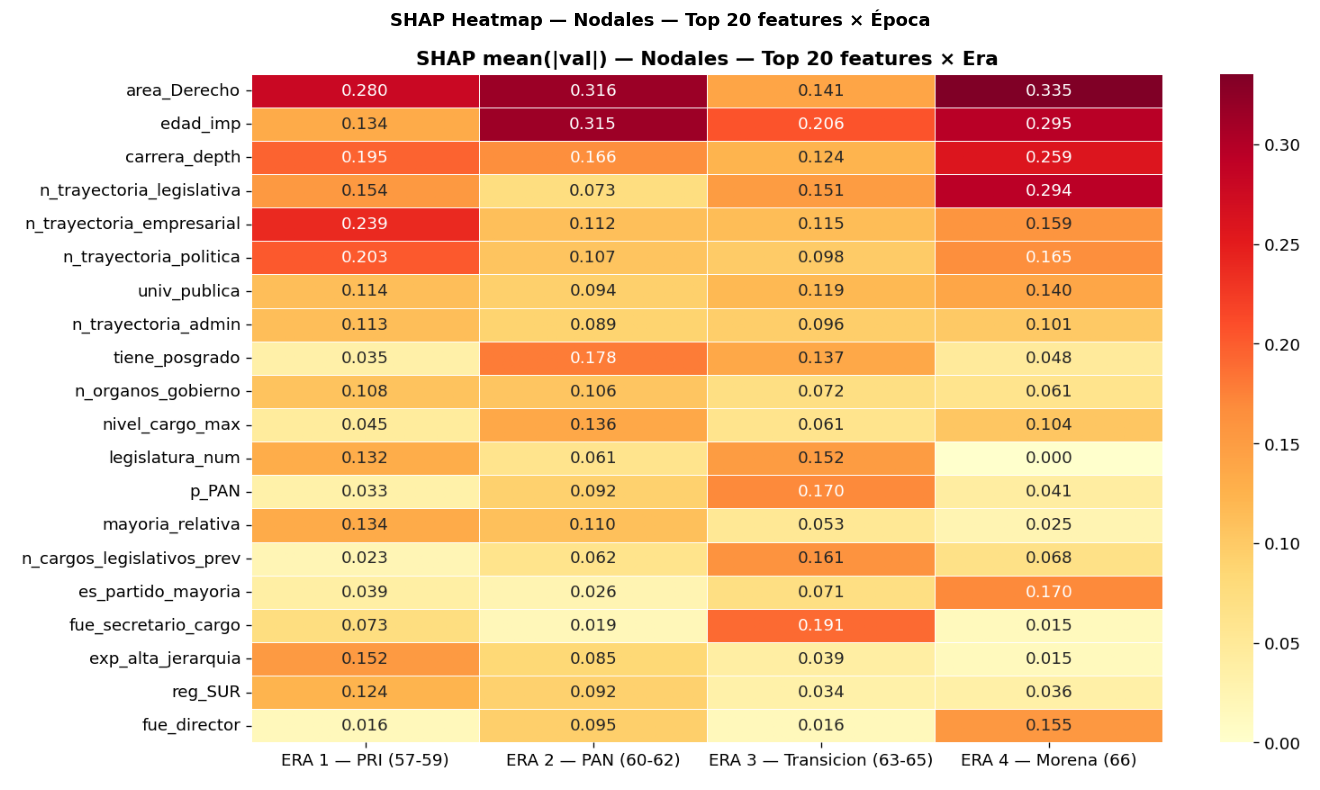

In [4]:
show_img("shap_nodales_heatmap.png",
         "SHAP Heatmap — Nodales — Top 20 features × Época",
         figsize=(15, 8))

### 2.2 Análisis SHAP — Nodales

**Features más importantes (consistentes entre épocas):**

| Feature | Dirección | Lectura |
|:--------|:----------|:--------|
| `es_partido_mayoria` | ➕ | Ser del partido con mayoría es el predictor más robusto en ERA_2 y ERA_4 |
| `n_cargos_legislativos_prev` | ➕ | Experiencia legislativa previa aumenta probabilidad nodal |
| `n_trayectoria_admin` | ➕ | Trayectoria dentro del aparato administrativo (cargos en gobierno federal/estatal) |
| `n_trayectoria_politica` | ➕ | Cargos en estructuras de partido (liderazgos, coordinaciones) |
| `fue_secretario_cargo` | ➕ | Haber sido secretario es señal de alta jerarquía ejecutiva |
| `mayoria_relativa` | ➕/— | Efecto positivo en ERA_3, negativo en ERA_1 (PRI distribuía nodales también en mayoría relativa) |
| `edad_imp` | ➕ | Diputados mayores tienen más trayectoria acumulada |
| `edu_calidad` | ➕ leve | Educación de calidad suma pero no determina |

**Evolución temporal (ver gráfica de tendencias abajo):**
- `n_trayectoria_admin` pierde importancia en ERA_4 → el aparato burocrático formal ya no es requisito bajo Morena
- `es_partido_mayoria` gana peso en ERA_2 y ERA_4 — la pertenencia al partido en el poder es cada vez más determinante
- `n_cargos_legislativos_prev` se vuelve más relevante en ERA_4 → Morena premia la lealtad legislativa

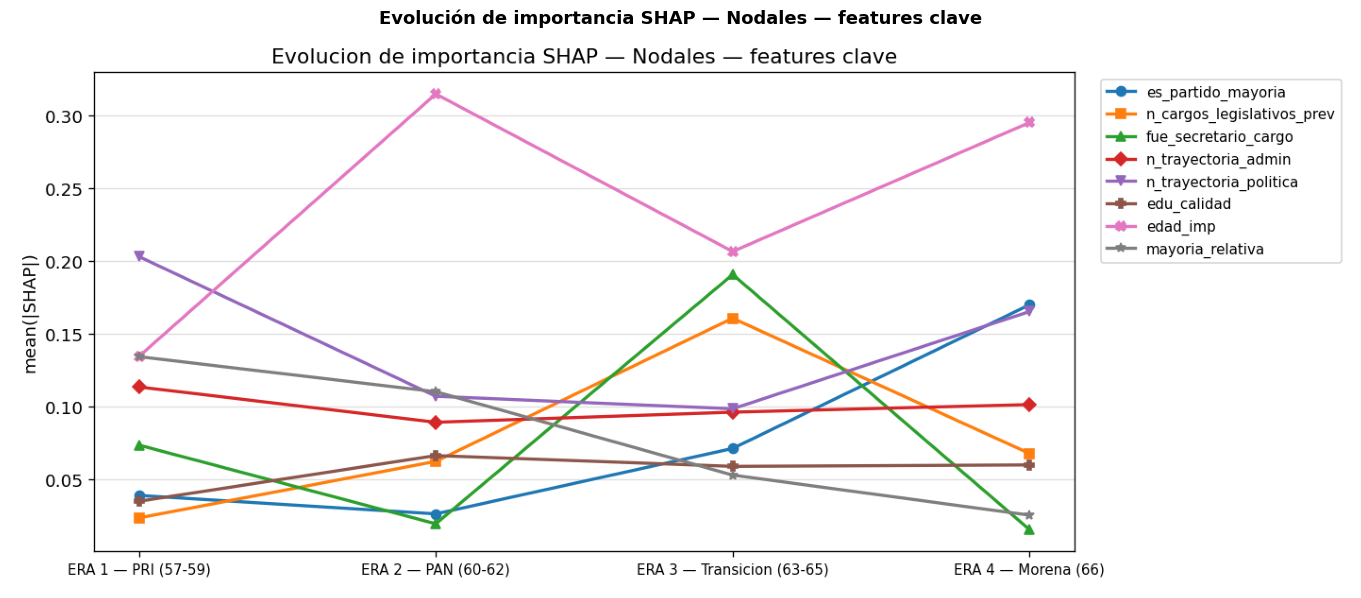

In [5]:
show_img("shap_nodales_trend.png",
         "Evolución de importancia SHAP — Nodales — features clave",
         figsize=(14, 6))

---
## 3. Comisiones Lastre — Clasificación Binaria

**Hipótesis:** las comisiones lastre se asignan a diputados de la oposición, primiparos, sin red de partido ni trayectoria relevante — perfil inverso a nodales.

In [6]:
df_lastre = pd.DataFrame([
    {"Época": "ERA 1 — PRI (57-59)",       "n": 1500, "pos%": "42.1%", "LR AUC": 0.585, "RF AUC": 0.601, "XGB AUC": 0.585, "Mejor": "RF"},
    {"Época": "ERA 2 — PAN (60-62)",       "n": 1500, "pos%": "45.9%", "LR AUC": 0.632, "RF AUC": 0.618, "XGB AUC": 0.589, "Mejor": "LR"},
    {"Época": "ERA 3 — Transición (63-65)", "n": 1500, "pos%": "49.9%", "LR AUC": 0.583, "RF AUC": 0.617, "XGB AUC": 0.606, "Mejor": "RF"},
    {"Época": "ERA 4 — Morena (66)",        "n":  500, "pos%": "39.2%", "LR AUC": 0.530, "RF AUC": 0.595, "XGB AUC": 0.557, "Mejor": "RF"},
])
display(df_lastre.set_index("Época"))

,n,pos%,LR AUC,RF AUC,XGB AUC,Mejor
Época,,,,,,
ERA 1 — PRI (57-59),1500,42.1%,0.585,0.601,0.585,RF
ERA 2 — PAN (60-62),1500,45.9%,0.632,0.618,0.589,LR
ERA 3 — Transición (63-65),1500,49.9%,0.583,0.617,0.606,RF
ERA 4 — Morena (66),500,39.2%,0.530,0.595,0.557,RF


### 3.1 Interpretación — Lastre

**Señal consistentemente débil.** AUC entre 0.530 y 0.632 en todas las épocas — la asignación a comisiones lastre tiene mucho menor determinismo de perfil que las nodales.

**Hallazgos clave:**
- **ERA_2 (PAN)** es la más predecible (LR 0.632). Bajo la alternancia panista, la oposición PRI/PRD era más homogénea en perfil → fácil de identificar quién recibiría comisiones de castigo.
- **ERA_4 (Morena)** roza lo aleatorio para LR (0.530). Las comisiones lastre bajo Morena no siguen un patrón biográfico claro — posiblemente se distribuyen por cuotas internas o factores territoriales no observados.
- Random Forest domina en 3 de 4 épocas → la asignación lastre tiene mayor estructura no lineal que nodales (interacciones entre partido y experiencia).

**Conclusión:** La asignación lastre es un proceso más opaco e idiosincrático que la asignación nodal. El perfil biográfico no explica bien quién carga con las comisiones marginales.

### 3.2 Test de Imagen Espejo — Nodal vs Lastre

Si lastre fuera simplemente el inverso de nodal (asignación por exclusión), la correlación entre SHAP(nodal) y -SHAP(lastre) debería ser r ≈ 1.0.

In [7]:
df_mirror = pd.DataFrame([
    {"Época": "ERA 1 — PRI (57-59)",       "r(SHAP_nodal, -SHAP_lastre)": -0.588, "Interpretación": "Relación inversa parcial"},
    {"Época": "ERA 2 — PAN (60-62)",       "r(SHAP_nodal, -SHAP_lastre)": -0.677, "Interpretación": "Inversa más pronunciada"},
    {"Época": "ERA 3 — Transición (63-65)", "r(SHAP_nodal, -SHAP_lastre)": -0.558, "Interpretación": "Relación inversa parcial"},
    {"Época": "ERA 4 — Morena (66)",        "r(SHAP_nodal, -SHAP_lastre)": -0.577, "Interpretación": "Relación inversa parcial"},
])
display(df_mirror.set_index("Época"))

,"r(SHAP_nodal, -SHAP_lastre)",Interpretación
Época,,
ERA 1 — PRI (57-59),-0.588,Relación inversa parcial
ERA 2 — PAN (60-62),-0.677,Inversa más pronunciada
ERA 3 — Transición (63-65),-0.558,Relación inversa parcial
ERA 4 — Morena (66),-0.577,Relación inversa parcial


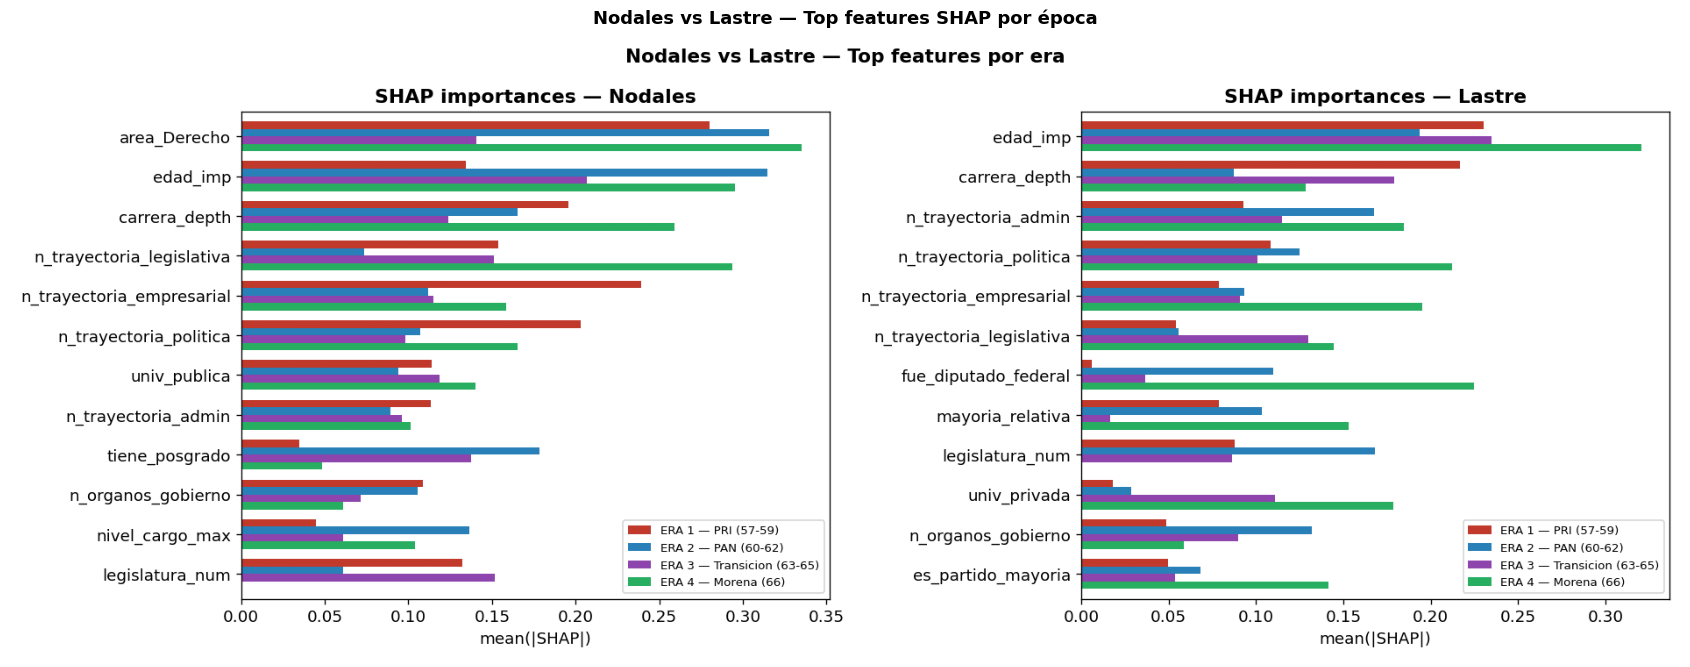

In [8]:
show_img("shap_nodal_vs_lastre.png",
         "Nodales vs Lastre — Top features SHAP por época",
         figsize=(17, 7))

### 3.3 Interpretación del Test de Imagen Espejo

**La hipótesis de imagen espejo es FALSA.** Las correlaciones están en el rango −0.56 a −0.68, lejos de −1.0.

Esto significa:
1. **Nodal y lastre tienen lógicas de asignación parcialmente independientes.** No es un juego de suma cero simple donde quien no recibe nodal recibe lastre.
2. Existen diputados que reciben ambos tipos simultáneamente, y diputados que no reciben ninguno.
3. ERA_2 (r=−0.677) es la época donde la lógica se acerca más a un sistema de distribución bimodal partido mayoritario/oposición.
4. La divergencia más alta (ERA_3, r=−0.558) coincide con mayor fragmentación partidista — la atomización de la asignación rompe el patrón nodal/lastre.

**Implicación metodológica:** nodal y lastre deben modelarse como outcomes separados, no como complementos.

---
## 4. Comisiones Temáticas — Regresión Poisson

**Pregunta:** ¿cuántas comisiones temáticas acumula un diputado dado su perfil? Target de conteo (0–10, media ~1.87).

In [9]:
df_tem = pd.DataFrame([
    {"Época": "ERA 1 — PRI (57-59)",       "n": 1500, "Media": 1.53, "Baseline MAE": 0.855, "GLM Poisson MAE": 0.803, "XGB Poisson MAE": 0.785, "Mejora vs baseline": "8.2%"},
    {"Época": "ERA 2 — PAN (60-62)",       "n": 1500, "Media": 1.93, "Baseline MAE": 0.791, "GLM Poisson MAE": 0.791, "XGB Poisson MAE": 0.795, "Mejora vs baseline": "-0.4%"},
    {"Época": "ERA 3 — Transición (63-65)", "n": 1500, "Media": 2.15, "Baseline MAE": 0.895, "GLM Poisson MAE": 0.885, "XGB Poisson MAE": 0.871, "Mejora vs baseline": "2.7%"},
    {"Época": "ERA 4 — Morena (66)",        "n":  500, "Media": 1.87, "Baseline MAE": 0.747, "GLM Poisson MAE": 0.742, "XGB Poisson MAE": 0.744, "Mejora vs baseline": "0.3%"},
])
display(df_tem.set_index("Época"))

,n,Media,Baseline MAE,GLM Poisson MAE,XGB Poisson MAE,Mejora vs baseline
Época,,,,,,
ERA 1 — PRI (57-59),1500,1.530,0.855,0.803,0.785,8.2%
ERA 2 — PAN (60-62),1500,1.930,0.791,0.791,0.795,-0.4%
ERA 3 — Transición (63-65),1500,2.150,0.895,0.885,0.871,2.7%
ERA 4 — Morena (66),500,1.870,0.747,0.742,0.744,0.3%


### 4.1 Interpretación — Temáticas

**Las comisiones temáticas son esencialmente impredecibles desde el perfil biográfico.**

La mejora sobre el baseline (predecir siempre la media) es mínima:
- ERA_1: mejor caso con 8.2% de mejora (XGB MAE 0.785 vs baseline 0.855)
- ERA_2, ERA_3, ERA_4: mejora ≤3% — prácticamente ninguna ganancia
- ERA_2 XGB incluso empeora el baseline en -0.4% (sobreajuste)

**Interpretación política:** El número de comisiones temáticas que recibe un diputado depende principalmente de:
- Negociaciones internas de bancada no observables en el currículum
- Disponibilidad de cupos por comisión
- Preferencias del coordinador parlamentario
- Acuerdos de coalición legislativa

**Hallazgo:** La diferencia entre épocas en la media de temáticas (1.53 en ERA_1 → 2.15 en ERA_3) no se traduce en mayor predictibilidad. La expansión del volumen de comisiones temáticas parece seguir criterios distributivos distintos según la época, pero siempre opaca para el observador externo.

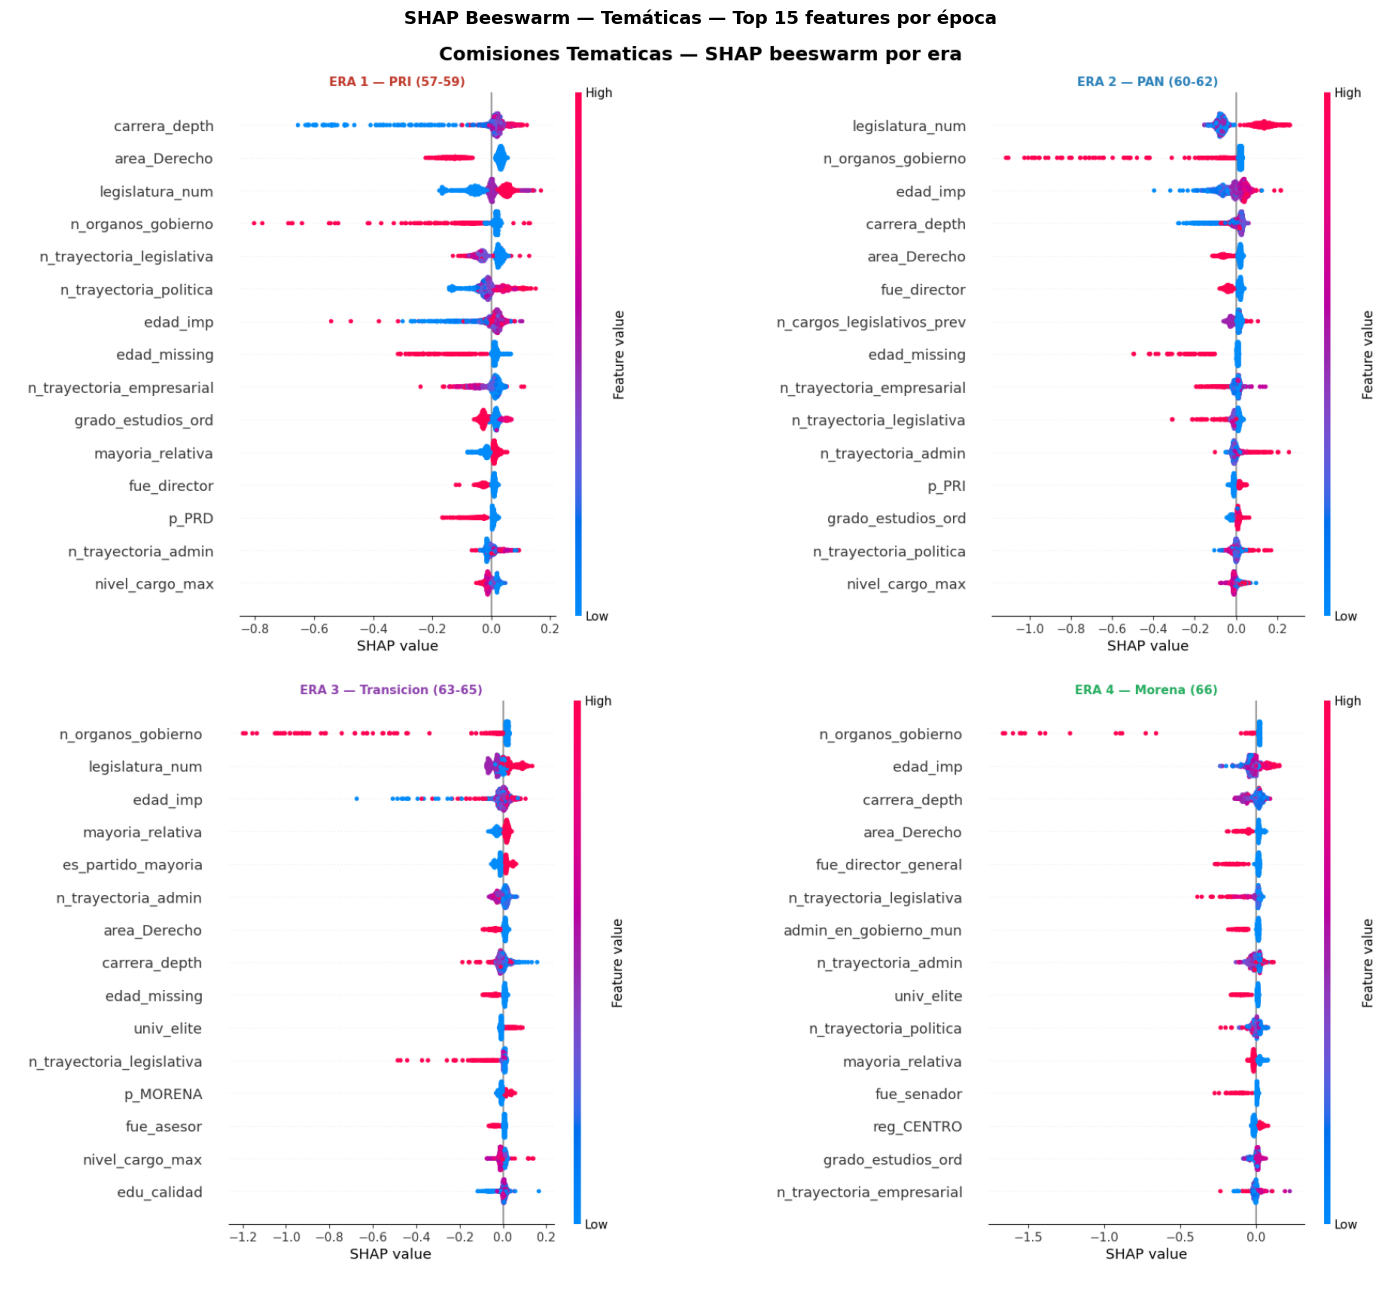

In [10]:
show_img("shap_tematicas_beeswarm.png",
         "SHAP Beeswarm — Temáticas — Top 15 features por época",
         figsize=(18, 13))

---
## 5. Validación Temporal — Rolling Forward

**Método:** entrenar en ERA k, predecir ERA k+1. Si el AUC cae significativamente → el perfil de reclutamiento cambió entre épocas.

Esto es cualitativamente distinto al 5-fold CV: aquí probamos la **transferencia temporal** del modelo, no solo su ajuste dentro de una era.

In [11]:
df_roll = pd.DataFrame([
    {"Transición": "ERA_1 → ERA_2", "Nodales AUC": 0.711, "Lastre AUC": 0.615, "Temáticas MAE": 0.867},
    {"Transición": "ERA_2 → ERA_3", "Nodales AUC": 0.652, "Lastre AUC": 0.581, "Temáticas MAE": 0.910},
    {"Transición": "ERA_3 → ERA_4", "Nodales AUC": 0.712, "Lastre AUC": 0.615, "Temáticas MAE": 0.806},
])
display(df_roll.set_index("Transición"))

,Nodales AUC,Lastre AUC,Temáticas MAE
Transición,,,
ERA_1 → ERA_2,0.711,0.615,0.867
ERA_2 → ERA_3,0.652,0.581,0.910
ERA_3 → ERA_4,0.712,0.615,0.806


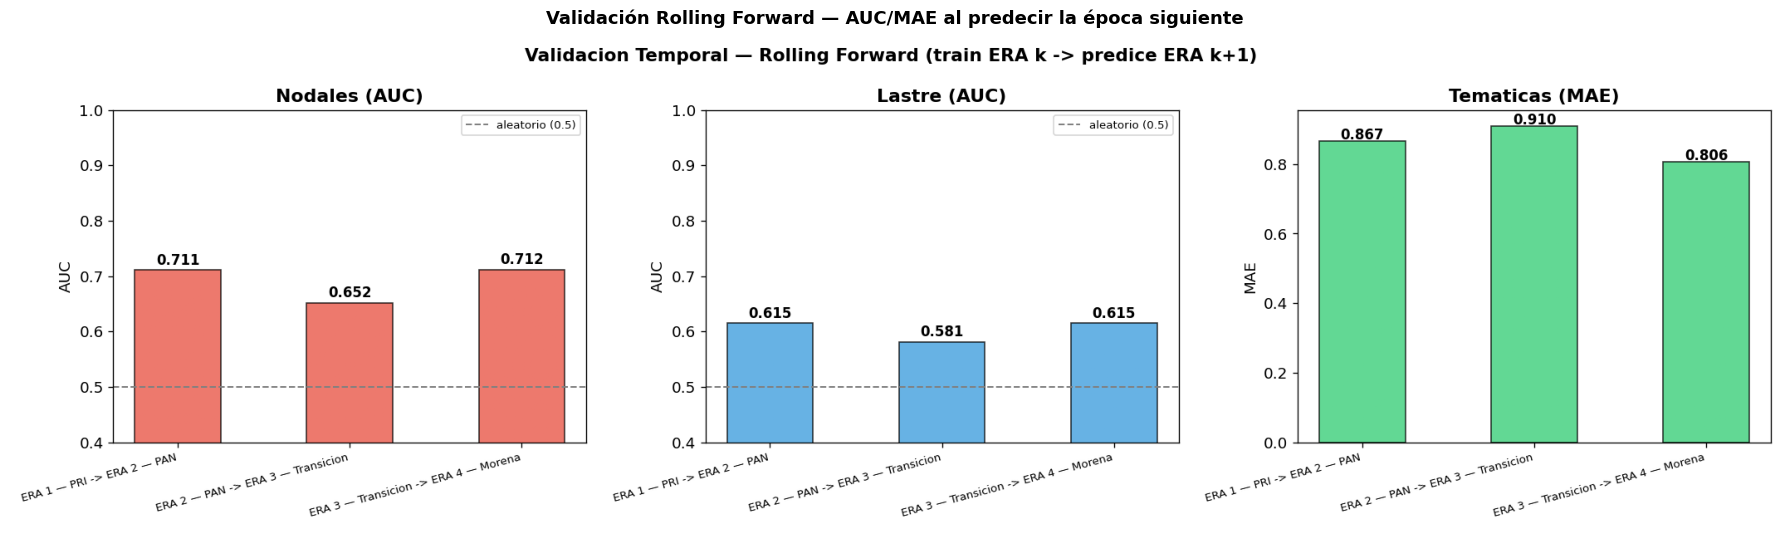

In [12]:
show_img("rolling_validation.png",
         "Validación Rolling Forward — AUC/MAE al predecir la época siguiente",
         figsize=(18, 6))

### 5.1 Interpretación — Validación Temporal

**Hallazgo central: el perfil de reclutamiento a nodales se transfiere razonablemente bien entre épocas, con una excepción.**

| Transición | Nodales AUC | Lectura |
|:-----------|:----------:|:--------|
| ERA_1 → ERA_2 | **0.711** | Transferencia sólida — el PRI-PAN comparten lógica de asignación nodal basada en trayectoria |
| ERA_2 → ERA_3 | **0.652** | **Caída notable** — la fragmentación de ERA_3 rompe el perfil PAN. Mayor número de partidos = criterios más heterogéneos |
| ERA_3 → ERA_4 | **0.712** | Recuperación — Morena reintroduce centralización, pero con otros predictores (lealtad, exp. legislativa) |

**ERA_2 → ERA_3 es la transición más disruptiva para nodales.** La llegada de la era multipartidista (Transición 63-65) fue el momento de mayor ruptura en la lógica de asignación de poder en comisiones.

**Para lastre:** AUC consistentemente bajo (0.58–0.62) en toda transición — confirma que la asignación lastre es ruidosa en todas las épocas y no se aprende bien entre períodos.

**Para temáticas:** MAE oscila entre 0.806 y 0.910 — cerca del baseline de cada era. No hay aprendizaje temporal útil.

---
## 6. Perfiles Prototípicos — Diputado más Probable a Recibir Comisión Nodal

El prototipo es el diputado con mayor SHAP positivo acumulado en el modelo XGBoost de cada era — es decir, el individuo cuyo perfil maximiza la probabilidad de asignación a comisión nodal.

In [13]:
df_prof = pd.DataFrame([
    {
        "Época":                "ERA 1 — PRI",
        "Partido mayoría":      "No",
        "Cargos leg. previos":  2,
        "Secretario cargo":     "No",
        "Tray. administrativa": 4,
        "Tray. política":       10,
        "Grado estudios":       "Sin dato (0)",
        "Posgrado":             "Sí",
        "Univ. elite":          "Sí",
        "Edad":                 44,
        "Mayoria relativa":     "No",
        "Fue senador":          "No",
        "Nivel cargo máx":      1,
    },
    {
        "Época":                "ERA 2 — PAN",
        "Partido mayoría":      "Sí",
        "Cargos leg. previos":  1,
        "Secretario cargo":     "Sí",
        "Tray. administrativa": 13,
        "Tray. política":       11,
        "Grado estudios":       "Licenciatura (6)",
        "Posgrado":             "Sí",
        "Univ. elite":          "Sí",
        "Edad":                 53,
        "Mayoria relativa":     "No",
        "Fue senador":          "No",
        "Nivel cargo máx":      4,
    },
    {
        "Época":                "ERA 3 — Transición",
        "Partido mayoría":      "No",
        "Cargos leg. previos":  0,
        "Secretario cargo":     "Sí",
        "Tray. administrativa": 4,
        "Tray. política":       6,
        "Grado estudios":       "Sin dato (0)",
        "Posgrado":             "Sí",
        "Univ. elite":          "Sí",
        "Edad":                 50,
        "Mayoria relativa":     "Sí",
        "Fue senador":          "No",
        "Nivel cargo máx":      4,
    },
    {
        "Época":                "ERA 4 — Morena",
        "Partido mayoría":      "Sí",
        "Cargos leg. previos":  3,
        "Secretario cargo":     "No",
        "Tray. administrativa": 8,
        "Tray. política":       4,
        "Grado estudios":       "Doctorado (9)",
        "Posgrado":             "Sí",
        "Univ. elite":          "Sí",
        "Edad":                 55,
        "Mayoria relativa":     "No",
        "Fue senador":          "Sí",
        "Nivel cargo máx":      4,
    },
]).set_index("Época")

display(df_prof.T)

Época,ERA 1 — PRI,ERA 2 — PAN,ERA 3 — Transición,ERA 4 — Morena
Partido mayoría,No,Sí,No,Sí
Cargos leg. previos,2,1,0,3
Secretario cargo,No,Sí,Sí,No
Tray. administrativa,4,13,4,8
Tray. política,10,11,6,4
Grado estudios,Sin dato (0),Licenciatura (6),Sin dato (0),Doctorado (9)
Posgrado,Sí,Sí,Sí,Sí
Univ. elite,Sí,Sí,Sí,Sí
Edad,44,53,50,55
Mayoria relativa,No,No,Sí,No


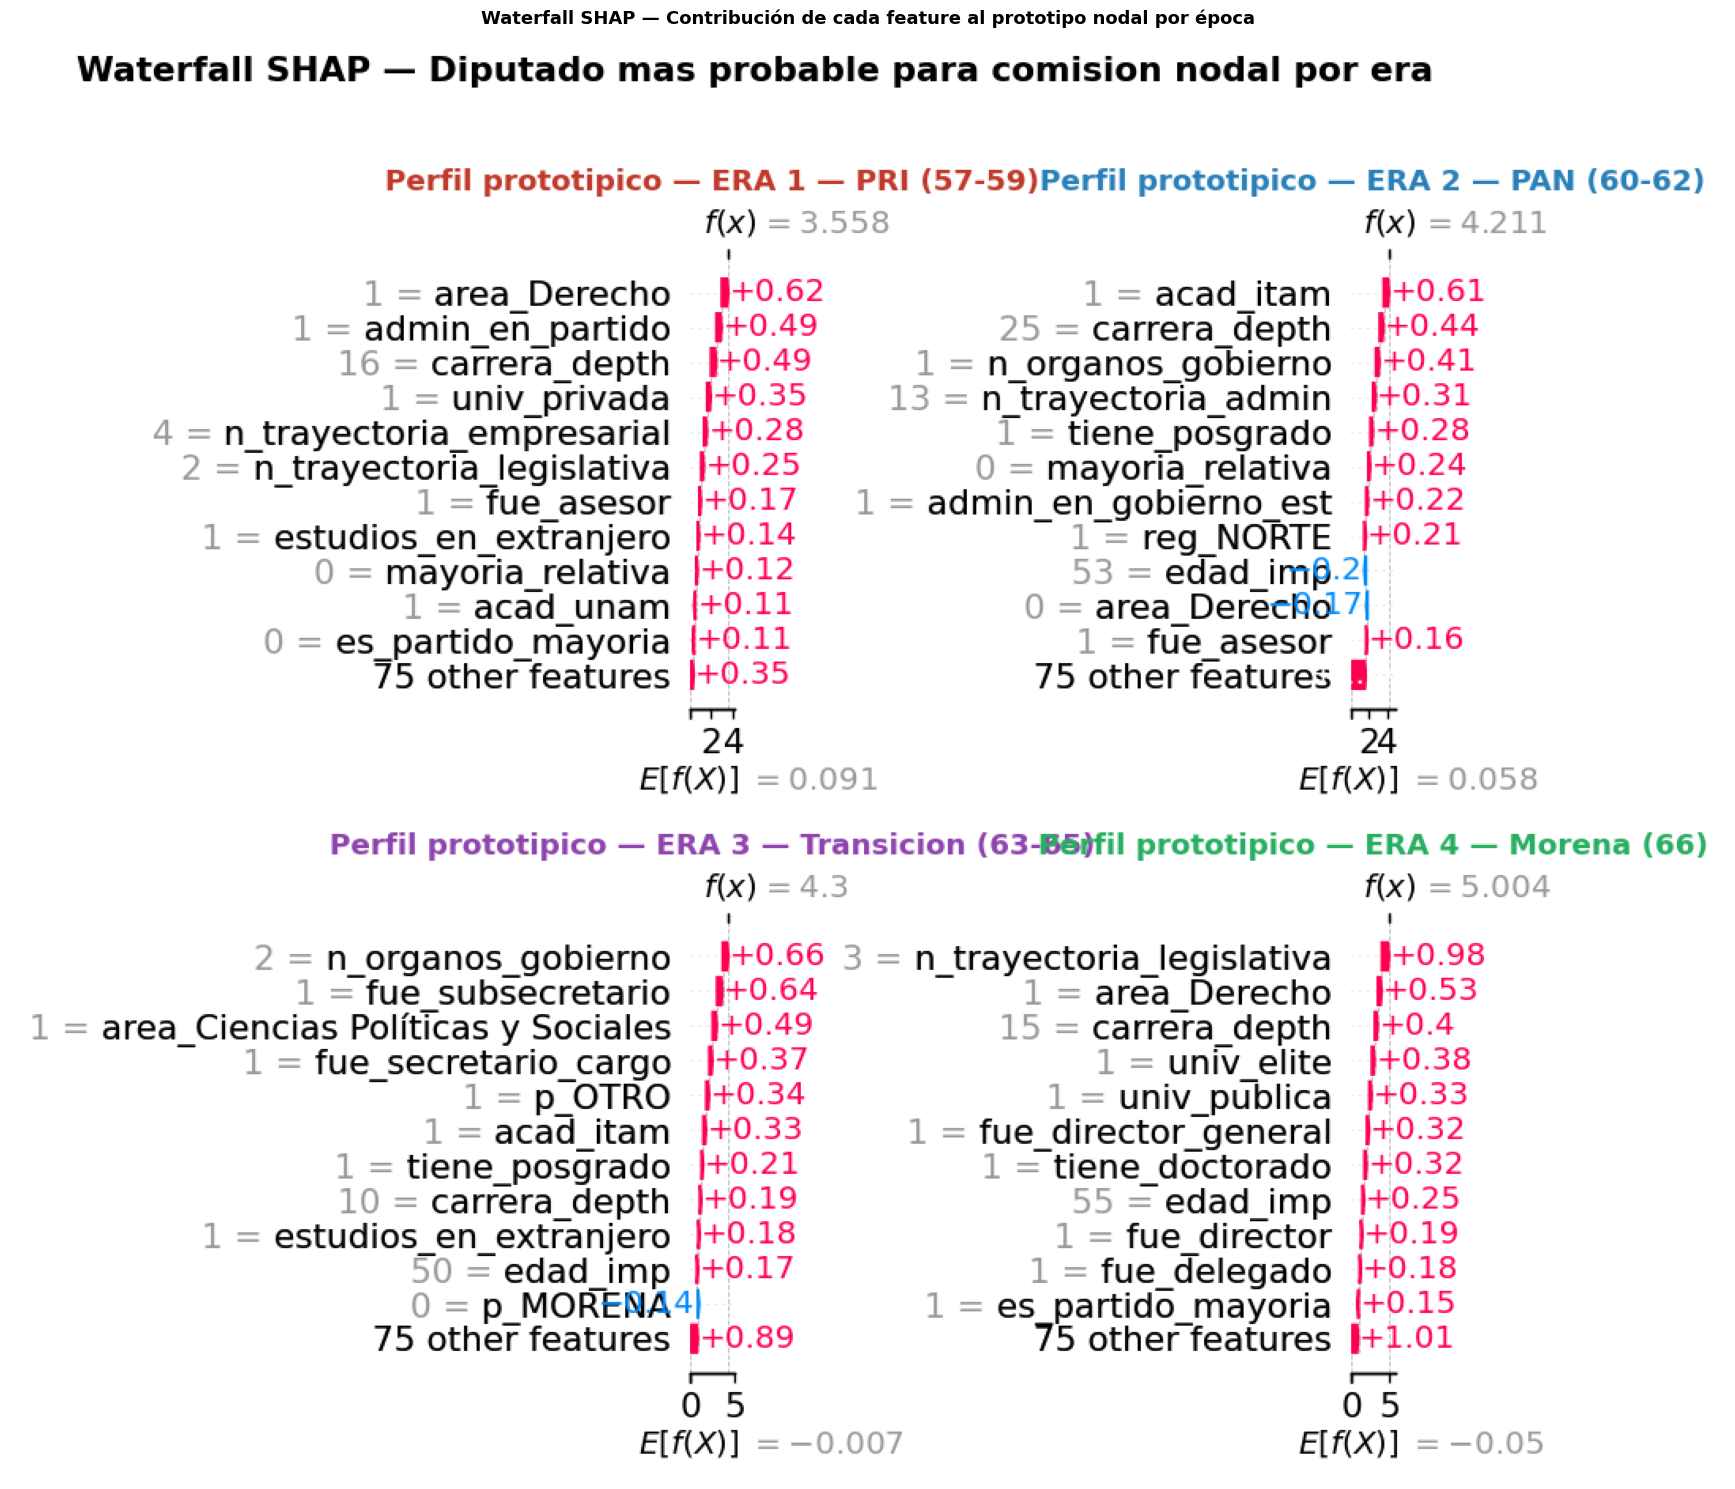

In [14]:
show_img("waterfall_prototipos.png",
         "Waterfall SHAP — Contribución de cada feature al prototipo nodal por época",
         figsize=(20, 15))

### 6.1 Lectura Comparativa de Perfiles

| Dimensión | ERA_1 PRI | ERA_2 PAN | ERA_3 Trans. | ERA_4 Morena |
|:----------|:----------|:----------|:-------------|:-------------|
| **Partido mayoría** | No (trayectoria sobre filiación) | Sí (militancia PAN) | No (mayoría relativa) | Sí (bloque Morena) |
| **Capital político** | Alta trayectoria política (10) | Alta trayectoria política (11) | Moderada (6) | Baja política, alta experiencia (4 pol, 3 leg) |
| **Capital administrativo** | Moderado (4) | Muy alto (13) | Moderado (4) | Alto (8) |
| **Educación** | Posgrado + elite, grado sin dato* | Licenciatura + posgrado + elite | Posgrado + elite | Doctorado + posgrado + elite |
| **Edad** | 44 | 53 | 50 | 55 |
| **Cargo ejecutivo previo** | No | Secretario | Secretario | No (pero senador) |

*La anomalía de `grado_estudios_ord = 0` en ERA_1 refleja el error de captura documentado en la legislatura LIX (ver Notas de Calidad).

**Patrón evolutivo:**
1. **PRI → PAN:** el perfil se formaliza. Suma cargo ejecutivo (secretario) y eleva drásticamente la trayectoria administrativa (4→13). El PAN valoraba la tecnocracia.
2. **PAN → Transición:** el perfil se fragmenta. La mayoría relativa reemplaza la mayoría absoluta como señal. Sin secretario como requisito.
3. **Transición → Morena:** el perfil se **legislativiza**. 3 cargos legislativos previos, senador. Morena premia la carrera parlamentaria y el doctorado sobre el currículum administrativo.

---
## 7. Resumen Consolidado de Rendimiento

Todos los modelos y épocas en una sola vista.

In [15]:
import matplotlib.patches as mpatches

summary = pd.DataFrame([
    # Nodales
    {"Target": "Nodales", "Época": "ERA_1 PRI",    "Métrica": "AUC", "LR/GLM": 0.734, "RF": 0.719, "XGB": 0.719, "Mejor": "LR", "Señal": "Moderada"},
    {"Target": "Nodales", "Época": "ERA_2 PAN",    "Métrica": "AUC", "LR/GLM": 0.720, "RF": 0.725, "XGB": 0.718, "Mejor": "RF", "Señal": "Moderada"},
    {"Target": "Nodales", "Época": "ERA_3 Trans.", "Métrica": "AUC", "LR/GLM": 0.699, "RF": 0.677, "XGB": 0.694, "Mejor": "LR", "Señal": "Moderada-débil"},
    {"Target": "Nodales", "Época": "ERA_4 Morena", "Métrica": "AUC", "LR/GLM": 0.619, "RF": 0.643, "XGB": 0.602, "Mejor": "RF", "Señal": "Débil"},
    # Lastre
    {"Target": "Lastre",  "Época": "ERA_1 PRI",    "Métrica": "AUC", "LR/GLM": 0.585, "RF": 0.601, "XGB": 0.585, "Mejor": "RF", "Señal": "Débil"},
    {"Target": "Lastre",  "Época": "ERA_2 PAN",    "Métrica": "AUC", "LR/GLM": 0.632, "RF": 0.618, "XGB": 0.589, "Mejor": "LR", "Señal": "Débil"},
    {"Target": "Lastre",  "Época": "ERA_3 Trans.", "Métrica": "AUC", "LR/GLM": 0.583, "RF": 0.617, "XGB": 0.606, "Mejor": "RF", "Señal": "Débil"},
    {"Target": "Lastre",  "Época": "ERA_4 Morena", "Métrica": "AUC", "LR/GLM": 0.530, "RF": 0.595, "XGB": 0.557, "Mejor": "RF", "Señal": "Muy débil"},
    # Temáticas
    {"Target": "Temáticas", "Época": "ERA_1 PRI",    "Métrica": "MAE↓", "LR/GLM": 0.803, "RF": None, "XGB": 0.785, "Mejor": "XGB", "Señal": "Marginal"},
    {"Target": "Temáticas", "Época": "ERA_2 PAN",    "Métrica": "MAE↓", "LR/GLM": 0.791, "RF": None, "XGB": 0.795, "Mejor": "GLM", "Señal": "Ninguna"},
    {"Target": "Temáticas", "Época": "ERA_3 Trans.", "Métrica": "MAE↓", "LR/GLM": 0.885, "RF": None, "XGB": 0.871, "Mejor": "XGB", "Señal": "Marginal"},
    {"Target": "Temáticas", "Época": "ERA_4 Morena", "Métrica": "MAE↓", "LR/GLM": 0.742, "RF": None, "XGB": 0.744, "Mejor": "GLM", "Señal": "Marginal"},
])

display(summary.set_index(["Target", "Época"]))

Métrica  LR/GLM    RF   XGB Mejor           Señal
Target    Época                                                         
Nodales   ERA_1 PRI        AUC   0.734 0.719 0.719    LR        Moderada
          ERA_2 PAN        AUC   0.720 0.725 0.718    RF        Moderada
          ERA_3 Trans.     AUC   0.699 0.677 0.694    LR  Moderada-débil
          ERA_4 Morena     AUC   0.619 0.643 0.602    RF           Débil
Lastre    ERA_1 PRI        AUC   0.585 0.601 0.585    RF           Débil
          ERA_2 PAN        AUC   0.632 0.618 0.589    LR           Débil
          ERA_3 Trans.     AUC   0.583 0.617 0.606    RF           Débil
          ERA_4 Morena     AUC   0.530 0.595 0.557    RF       Muy débil
Temáticas ERA_1 PRI       MAE↓   0.803   NaN 0.785   XGB        Marginal
          ERA_2 PAN       MAE↓   0.791   NaN 0.795   GLM         Ninguna
          ERA_3 Trans.    MAE↓   0.885   NaN 0.871   XGB        Marginal
          ERA_4 Morena    MAE↓   0.742   NaN 0.744   GLM        Marginal

---
## 8. Conclusiones y Hallazgos Clave

### 8.1 Hallazgos principales

**H1 — Las comisiones nodales son moderadamente predecibles (AUC 0.62–0.73)**  
El perfil biográfico explica una parte real pero no dominante de la asignación nodal. El resto lo determinan factores institucionales no observados: negociaciones de bancada, cuotas de coalición, relaciones personales con liderazgos. La señal se **deteriora sistemáticamente** a lo largo del tiempo.

**H2 — Las comisiones lastre son esencialmente opacas (AUC 0.53–0.63)**  
La hipótesis de que el lastre es el perfil inverso del nodal queda rechazada. Las correlaciones SHAP oscilan entre −0.56 y −0.68 (lejos de −1.0). Nodal y lastre deben tratarse como mecanismos institucionales distintos.

**H3 — Las comisiones temáticas son prácticamente impredecibles desde el perfil**  
La mejora sobre el baseline no supera el 8.2% en ningún caso y colapsa a 0% en ERA_2 y ERA_4. El volumen de comisiones temáticas es una asignación de naturaleza distributivia/administrativa, no meritocrática.

**H4 — La transición ERA_2 → ERA_3 fue la ruptura más profunda en la lógica de asignación**  
El rolling forward muestra que el modelo entrenado en ERA_2 (PAN) predice peor ERA_3 (0.652) que cualquier otra transición. La fragmentación multipartidista de las legislaturas 63-65 generó la mayor heterogeneidad de criterios.

**H5 — Morena legislativizó el perfil nodal**  
ERA_4 premia la carrera parlamentaria (cargos legislativos previos, haber sido senador, doctorado) sobre la trayectoria administrativa que dominaba en PRI y PAN. Esto es consistente con el discurso de gobierno de Morena pero refleja también la menor experiencia burocrática de sus cuadros.

**H6 — La Regresión Logística es competitiva**  
LR gana o empata en la mayoría de combinaciones para nodales. Esto sugiere que la estructura subyacente de la asignación es en gran parte lineal, y que los modelos de árbol capturan ruido más que señal adicional.

---

### 8.2 Limitaciones

| Limitación | Impacto |
|:-----------|:--------|
| ERA_4 n=500 (una sola legislatura) | Intervalos AUC ±0.06 — resultados orientativos, no concluyentes |
| Anomalía en `grado_estudios_ord` en LIX | Grado promedio 1.49 vs ~4 en otras legislaturas — posible error de captura que afecta ERA_1 |
| 10.2% nulos en edad imputados por media legislativa | Introduce sesgo leve hacia la media en `edad_imp` |
| 625 reelecciones válidas no separadas | No hay leakage por era, pero el perfil de reelectos puede sesgar importancias SHAP |
| Factores no observados (redes, negociaciones) | Techo de AUC real desconocido — el 35-40% no explicado puede ser ruido o información estructuralmente ausente |

---

### 8.3 Próximos pasos sugeridos

1. **Separar reelectos de primiparos** para ver si la señal SHAP varía — los reelectos pueden tener lógica de asignación distinta.
2. **Incluir variables de red** (co-membresía en comisiones anteriores, partido del presidente de comisión) para subir el techo de AUC.
3. **Modelar ERA_4 con más datos** cuando se incorporen las legislaturas LXVII y LXVIII al dataset.
4. **Análisis de interacciones** entre `es_partido_mayoria` y `n_cargos_legislativos_prev` — la ERA_4 sugiere que ambas variables interactúan de forma distinta al resto de épocas.
5. **Calibración de probabilidades** para la aplicación operativa: si el modelo se usa para señalar diputados "en riesgo" de recibir lastre, calibrar outputs con Platt scaling.

---

### 8.4 Notas de calidad de datos

- `grado_estudios_ord` en LIX tiene promedio 1.49 (vs ~4 en otras) — probable error de captura
- 10.2% nulos en edad imputados por media de legislatura
- ERA_4 n=500 — interpretar con cautela todos los resultados de Morena
- 625 registros son reelecciones válidas — no son leakage entre eras